<a href="https://colab.research.google.com/github/Sachinkmr101/COMPARATIVE-ANALYSIS-OF-TRANSFER-LEARNING-MODELS-FOR-MEDICAL-IMAGE-CLASSIFICATION/blob/main/2MRI_Image_Classification_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Comparative Analysis of Transfer Learning Models for Medical Image Classification
### Dissertation — Chapter 4 Implementation
**Models:** VGG16 | ResNet50 | DenseNet121  
**Dataset:** Brain Tumor MRI (Kaggle)  
**Metrics:** Accuracy, Precision, Recall, F1-Score, AUC-ROC

---
> **How to use:** Runtime → Change runtime type → T4 GPU → Run All

## ✅ Step 1 — Install Dependencies & Setup

In [1]:
# Install required libraries
!pip install -q kaggle matplotlib seaborn scikit-learn tensorflow

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')
print('✅ All libraries loaded successfully!')

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries loaded successfully!


## ✅ Step 2 — Download Dataset from Kaggle

> **Setup Kaggle API (one-time):**
> 1. Go to https://www.kaggle.com → Account → Create New Token
> 2. Download `kaggle.json`
> 3. Upload it below when prompted

In [2]:
from google.colab import files

# Upload kaggle.json
print('Please upload your kaggle.json file:')
uploaded = files.upload()

# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Download Brain Tumor MRI Dataset (3264 images, 4 classes)
print('\nDownloading Brain Tumor MRI Dataset...')
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri --unzip -p /content/dataset

print('\n✅ Dataset downloaded!')
!find /content/dataset -type d | head -20

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:00<00:00, 99.8MB/s]


✅ Dataset downloaded!
/content/dataset
/content/dataset/Testing
/content/dataset/Testing/no_tumor
/content/dataset/Testing/glioma_tumor
/content/dataset/Testing/pituitary_tumor
/content/dataset/Testing/meningioma_tumor
/content/dataset/Training
/content/dataset/Training/no_tumor
/content/dataset/Training/glioma_tumor
/content/dataset/Training/pituitary_tumor
/content/dataset/Training/meningioma_tumor


## ✅ Step 3 — Configuration & Hyperparameters

In [3]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
# Paths — adjust if your dataset folder structure is different
TRAIN_DIR  = '/content/dataset/Training'
TEST_DIR   = '/content/dataset/Testing'

# Hyperparameters (matches dissertation Chapter 3 methodology)
IMG_SIZE    = (224, 224)       # All 3 models use 224x224
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-4             # Adam learning rate
PATIENCE    = 10               # Early stopping patience
DROPOUT     = 0.5
NUM_CLASSES = 4                # glioma, meningioma, no_tumor, pituitary

CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print('Configuration:')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Learning rate: {LR}')
print(f'  Early stop   : patience={PATIENCE}')
print(f'  Classes      : {CLASS_NAMES}')

Configuration:
  Image size   : (224, 224)
  Batch size   : 32
  Max epochs   : 50
  Learning rate: 0.0001
  Early stop   : patience=10
  Classes      : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## ✅ Step 4 — Data Preprocessing & Augmentation

In [4]:
# Training augmentation (matches dissertation Section 3.4.2)
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    shear_range       = 0.15,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    fill_mode         = 'nearest',
    validation_split  = 0.2    # 80% train, 20% val from Training folder
)

# Test / Validation — only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=42, shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

print(f'\nTrain samples      : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Test samples       : {test_gen.samples}')
print(f'Class indices      : {train_gen.class_indices}')

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

Train samples      : 2297
Validation samples : 573
Test samples       : 394
Class indices      : {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


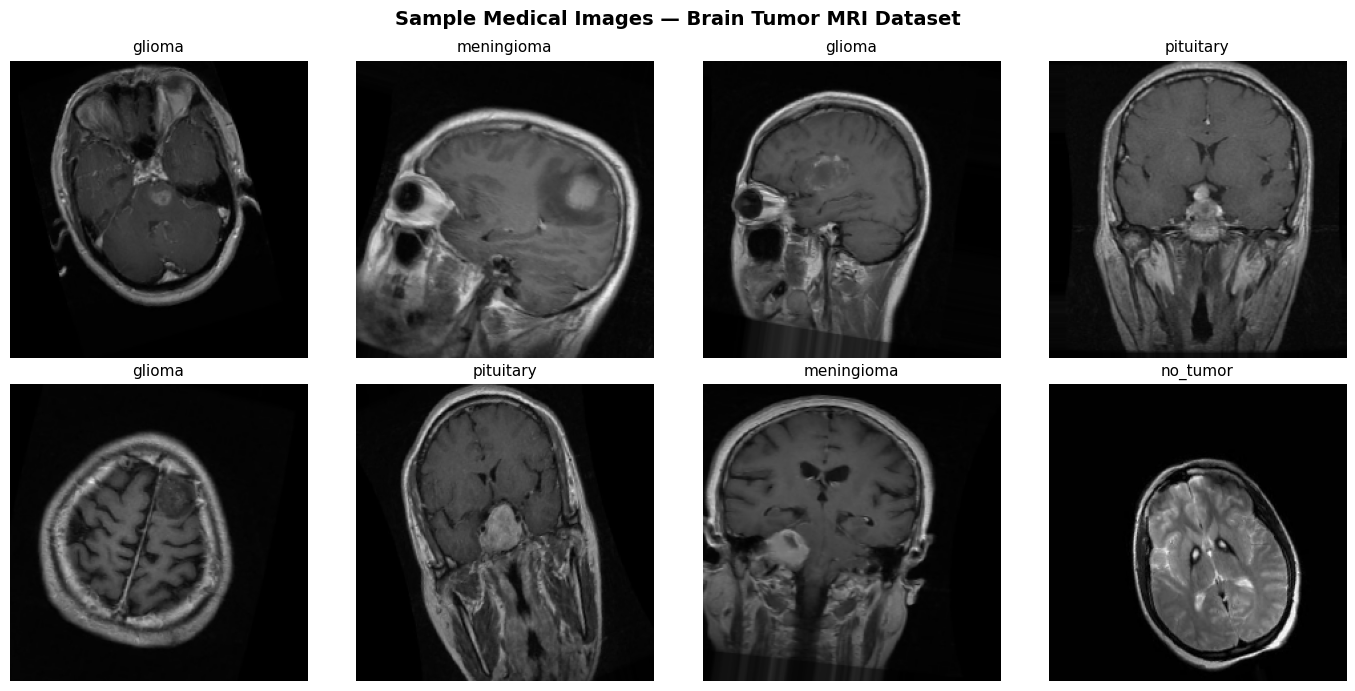

✅ Sample images visualised


In [5]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Medical Images — Brain Tumor MRI Dataset', fontsize=14, fontweight='bold')

imgs, labels = next(train_gen)
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images visualised')

## ✅ Step 5 — Build Transfer Learning Models
### Fine-tuning strategy: freeze base → train classifier → unfreeze top block → fine-tune

In [6]:
def build_model(base_name, num_classes=4, dropout=0.5, lr=1e-4):
    """
    Build a transfer learning model using fine-tuning strategy.
    Phase 1: Only classifier head is trained.
    Phase 2: Top convolutional block + head fine-tuned (low lr).
    Returns model ready for Phase 1 training.
    """
    input_shape = (224, 224, 3)

    if base_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'block5_conv1'   # Last conv block for fine-tuning
    elif base_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    elif base_name == 'DenseNet121':
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    else:
        raise ValueError(f'Unknown model: {base_name}')

    # Phase 1: Freeze entire base
    base.trainable = False

    # Classifier head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base, unfreeze_from


def unfreeze_top_block(model, base, unfreeze_from, lr=1e-5):
    """Phase 2: Unfreeze top convolutional block for fine-tuning."""
    base.trainable = True
    found = False
    for layer in base.layers:
        if layer.name == unfreeze_from:
            found = True
        layer.trainable = found

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Unfrozen from: {unfreeze_from} | Trainable layers: {trainable}')
    return model


print('✅ Model builder functions defined')

✅ Model builder functions defined


## ✅ Step 6 — Training Loop (All 3 Models)

In [7]:
def train_model(model_name):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    model, base, unfreeze_from = build_model(model_name, NUM_CLASSES, DROPOUT, LR)
    print(f'Total params: {model.count_params():,}')

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

    # ── Phase 1: Train classifier head only ──
    print('\nPhase 1: Training classifier head (base frozen)...')
    hist1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=20, callbacks=callbacks, verbose=1
    )

    # ── Phase 2: Fine-tune top convolutional block ──
    print('\nPhase 2: Fine-tuning top convolutional block...')
    model = unfreeze_top_block(model, base, unfreeze_from, lr=LR/10)

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-8, verbose=1),
        ModelCheckpoint(f'{model_name}_finetuned.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]
    hist2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=callbacks_ft, verbose=1
    )

    # Merge histories
    history = {}
    for k in hist1.history:
        history[k] = hist1.history[k] + hist2.history[k]

    return model, history


# Train all three models
models_trained  = {}
histories       = {}

for name in ['VGG16', 'ResNet50', 'DenseNet121']:
    model, history = train_model(name)
    models_trained[name]  = model
    histories[name]       = history

print('\n✅ All models trained successfully!')


  Training: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 15,111,748

Phase 1: Training classifier head (base frozen)...
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.4028 - loss: 1.3845

72/72 ━━━━━━━━━━━━━━━━━━━━ 88s 920ms/step - accuracy: 0.4980 - loss: 1.1911 - val_accuracy: 0.3997 - val_loss: 1.3081 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6381 - loss: 0.9366

72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 589ms/step - accuracy: 0.6391 - loss: 0.9076 - val_accuracy: 0.4869 - val_loss: 1.2150 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6840 - loss: 0.8106

72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 560ms/step - accuracy: 0.6931 - loss: 0.7822 - val_accuracy: 0.5864 - val_loss: 1.0992 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7313 - loss: 0.6975

72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 572ms/step - accuracy: 0.7353 - loss: 0.6900 - val_accuracy: 0.6091 - val_loss: 0.9930 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7438 - loss: 0.6446

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 581ms/step - accuracy: 0.8616 - loss: 0.3558 - val_accuracy: 0.8080 - val_loss: 0.5413 - learning_rate: 1.0000e-04
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 0.8759 - loss: 0.3386 - val_accuracy: 0.8028 - val_loss: 0.5388 - learning_rate: 1.0000e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 581ms/step - accuracy: 0.8646 - loss: 0.3503 - val_accuracy: 0.7993 - val_loss: 0.5276 - learning_rate: 1.0000e-04
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8868 - loss: 0.3104

72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 601ms/step - accuracy: 0.8798 - loss: 0.3202 - val_accuracy: 0.8133 - val_loss: 0.4822 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8739 - loss: 0.3370

72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 583ms/step - accuracy: 0.8829 - loss: 0.3116 - val_accuracy: 0.8325 - val_loss: 0.5325 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 576ms/step - accuracy: 0.8790 - loss: 0.3101 - val_accuracy: 0.8080 - val_loss: 0.5210 - learning_rate: 1.0000e-04
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 591ms/step - accuracy: 0.8977 - loss: 0.2887 - val_accuracy: 0.8010 - val_loss: 0.5283 - learning_rate: 1.0000e-04
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 575ms/step - accuracy: 0.8920 - loss: 0.2930 - val_accuracy: 0.8272 - val_loss: 0.4956 - learning_rate: 1.0000e-04
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.8884 - loss: 0.2817
Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 583ms/step - accuracy: 0.8938 - loss: 0.2787 - val_accuracy: 0.8168 - val_loss: 0.4955 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 16.

Phase 2: 

72/72 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8825 - loss: 0.3077 - val_accuracy: 0.8202 - val_loss: 0.4897 - learning_rate: 1.0000e-05
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 576ms/step - accuracy: 0.8833 - loss: 0.3025 - val_accuracy: 0.8115 - val_loss: 0.5224 - learning_rate: 1.0000e-05
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.8859 - loss: 0.2927 - val_accuracy: 0.8168 - val_loss: 0.5045 - learning_rate: 1.0000e-05
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 592ms/step - accuracy: 0.8877 - loss: 0.3095 - val_accuracy: 0.8080 - val_loss: 0.5248 - learning_rate: 1.0000e-05
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy: 0.8942 - loss: 0.2920 - val_accuracy: 0.7923 - val_loss: 0.5266 - learning_rate: 1.0000e-05
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8975 - loss: 0.2854
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 572ms/step - accuracy: 0.8890 - los

72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 600ms/step - accuracy: 0.8886 - loss: 0.2847 - val_accuracy: 0.8360 - val_loss: 0.4858 - learning_rate: 5.0000e-06
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 575ms/step - accuracy: 0.8916 - loss: 0.2859 - val_accuracy: 0.8255 - val_loss: 0.5063 - learning_rate: 5.0000e-06
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 574ms/step - accuracy: 0.8877 - loss: 0.2882 - val_accuracy: 0.8080 - val_loss: 0.5119 - learning_rate: 5.0000e-06
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 578ms/step - accuracy: 0.8912 - loss: 0.3016 - val_accuracy: 0.8028 - val_loss: 0.5158 - learning_rate: 5.0000e-06
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 574ms/step - accuracy: 0.8851 - loss: 0.3164 - val_accuracy: 0.8220 - val_loss: 0.5019 - learning_rate: 5.0000e-06
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8846 - loss: 0.2890
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 0.8933

## ✅ Step 7 — Evaluate All Models

In [8]:
from sklearn.preprocessing import label_binarize

results = {}

for name, model in models_trained.items():
    print(f'\nEvaluating {name}...')
    test_gen.reset()

    # Predictions
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = test_gen.classes

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # AUC-ROC (one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        auc_scores.append(auc(fpr, tpr))
    mean_auc = np.mean(auc_scores)

    results[name] = {
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'auc'       : mean_auc,
        'y_pred'    : y_pred,
        'y_true'    : y_true,
        'y_proba'   : y_pred_proba,
        'auc_scores': auc_scores
    }

    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {mean_auc:.4f}')

print('\n✅ Evaluation complete!')


Evaluating VGG16...
  Accuracy  : 0.7259 (72.59%)
  Precision : 0.8191
  Recall    : 0.7088
  F1-Score  : 0.6774
  AUC-ROC   : 0.9009

Evaluating ResNet50...
  Accuracy  : 0.5000 (50.00%)
  Precision : 0.5717
  Recall    : 0.4890
  F1-Score  : 0.4575
  AUC-ROC   : 0.7322

Evaluating DenseNet121...
  Accuracy  : 0.6751 (67.51%)
  Precision : 0.7161
  Recall    : 0.6604
  F1-Score  : 0.6360
  AUC-ROC   : 0.8729

✅ Evaluation complete!


## ✅ Step 8 — Results Summary Table

In [ ]:
print('\n' + '='*70)
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('='*70)

for name, r in results.items():
    print(f'{name:<15} '
          f'{r["accuracy"]*100:>9.2f}% '
          f'{r["precision"]:>10.4f} '
          f'{r["recall"]:>10.4f} '
          f'{r["f1"]:>10.4f} '
          f'{r["auc"]:>10.4f}')

print('='*70)

best = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model: {best} (Accuracy: {results[best]["accuracy"]*100:.2f}%)')

## ✅ Step 9 — Training & Validation Curves

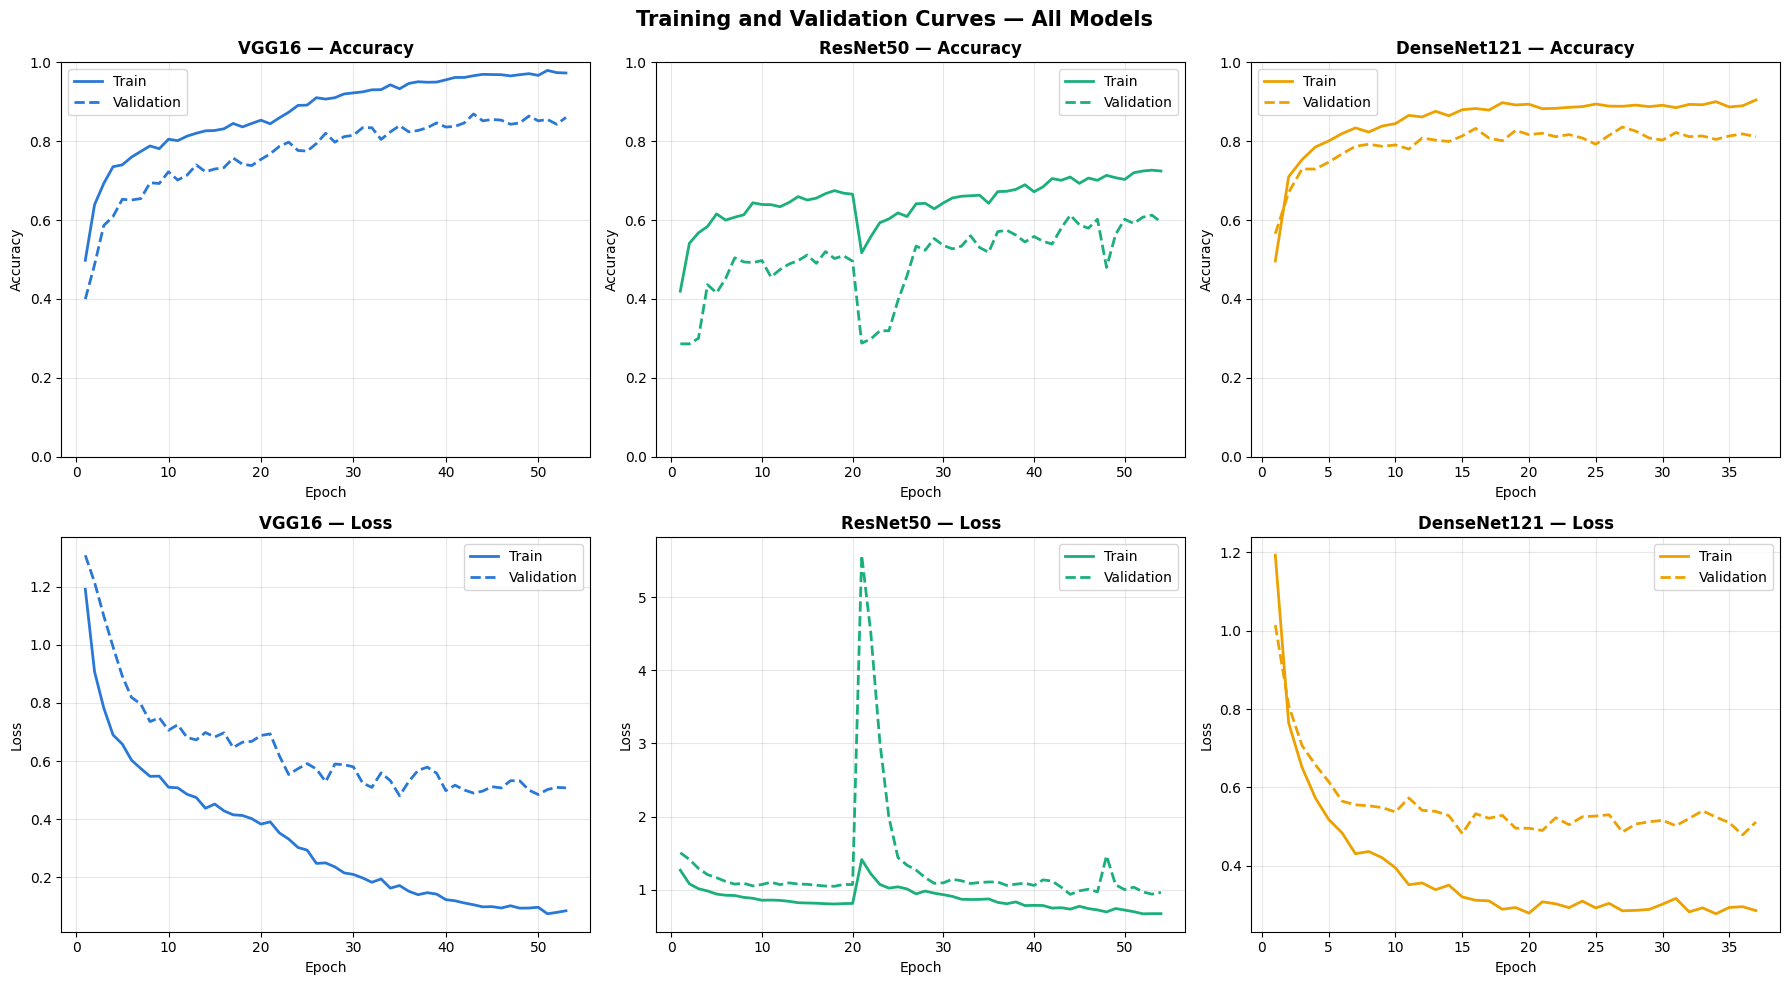

✅ Training curves saved


In [10]:
colors = {'VGG16': '#2a78d6', 'ResNet50': '#1baf7a', 'DenseNet121': '#eda100'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training and Validation Curves — All Models', fontsize=15, fontweight='bold')

for col, (name, hist) in enumerate(histories.items()):
    color = colors[name]
    epochs_ran = range(1, len(hist['accuracy']) + 1)

    # Accuracy
    ax = axes[0, col]
    ax.plot(epochs_ran, hist['accuracy'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_accuracy'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    # Loss
    ax = axes[1, col]
    ax.plot(epochs_ran, hist['loss'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_loss'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## ✅ Step 10 — Confusion Matrices

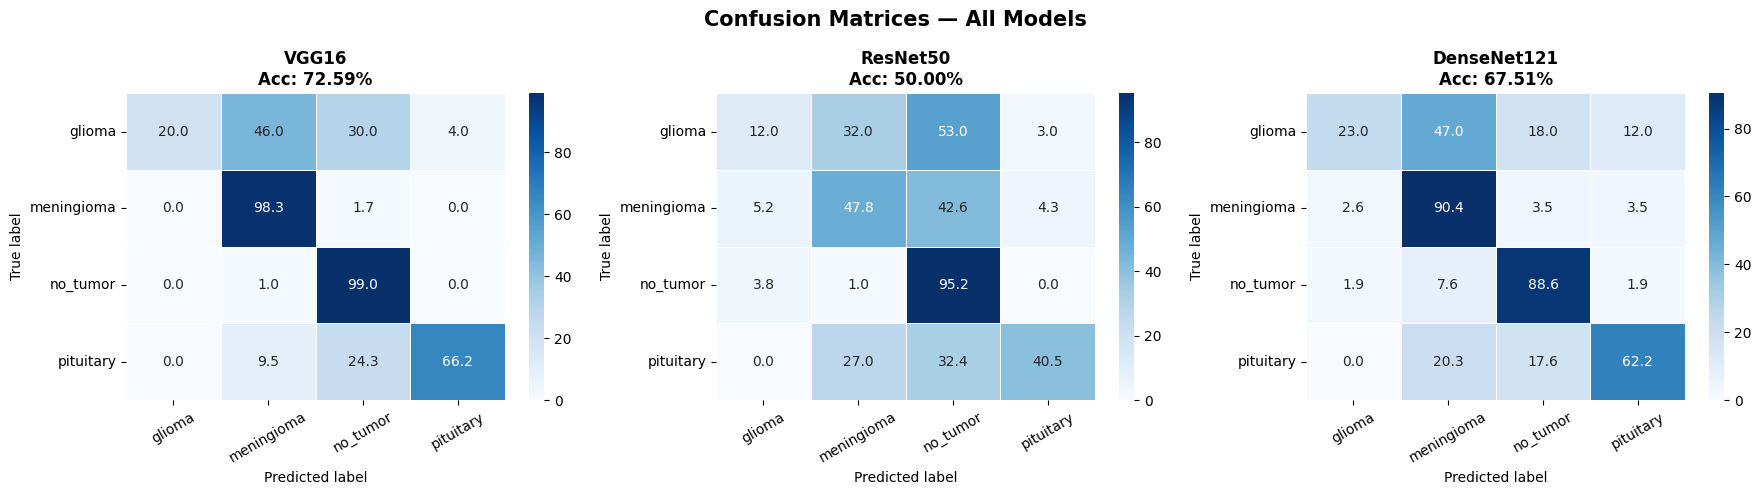

✅ Confusion matrices saved


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues', linewidths=0.5,
        annot_kws={'size': 10}
    )
    ax.set_title(f'{name}\nAcc: {r["accuracy"]*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

## ✅ Step 11 — ROC Curves (AUC-ROC)

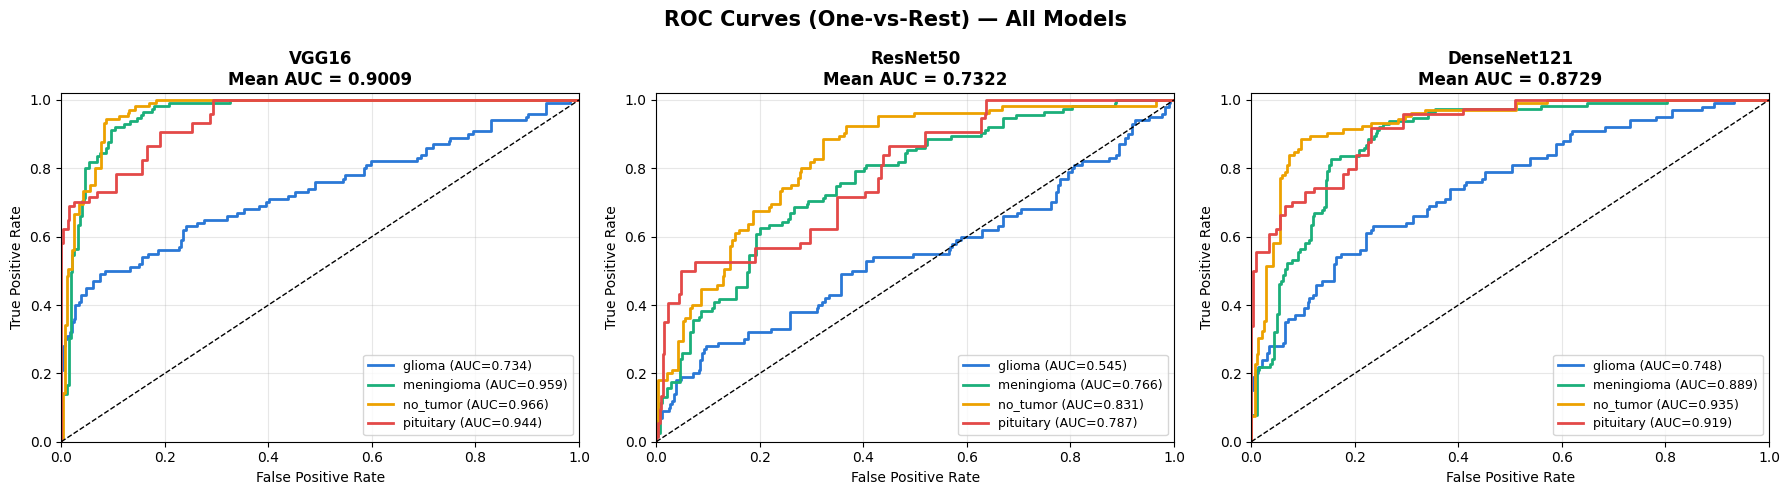

✅ ROC curves saved


In [12]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves (One-vs-Rest) — All Models', fontsize=15, fontweight='bold')

class_colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']

for ax, (name, r) in zip(axes, results.items()):
    y_true_bin = label_binarize(r['y_true'], classes=[0,1,2,3])

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], r['y_proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=class_colors[i], linewidth=2,
                label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'{name}\nMean AUC = {r["auc"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved')

## ✅ Step 12 — Bar Chart Comparison (Dissertation Figure)

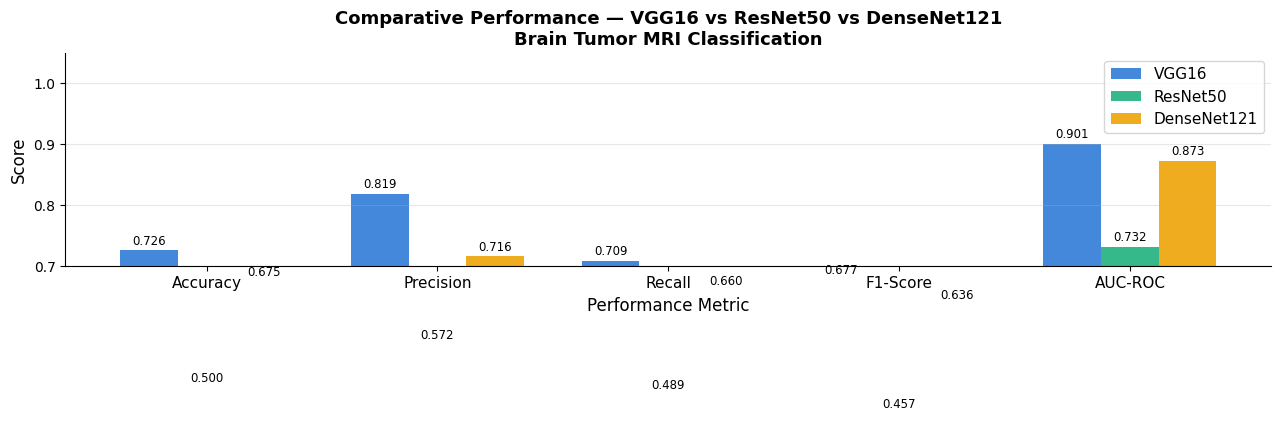

✅ Comparison bar chart saved


In [13]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = list(results.keys())
bar_colors  = ['#2a78d6', '#1baf7a', '#eda100']

data = {
    name: [
        r['accuracy'], r['precision'],
        r['recall'],   r['f1'], r['auc']
    ]
    for name, r in results.items()
}

x        = np.arange(len(metrics))
bar_w    = 0.25
fig, ax  = plt.subplots(figsize=(13, 6))

for i, (name, vals) in enumerate(data.items()):
    bars = ax.bar(x + i*bar_w, vals, bar_w,
                  label=name, color=bar_colors[i], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Performance Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparative Performance — VGG16 vs ResNet50 vs DenseNet121\nBrain Tumor MRI Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + bar_w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0.7, 1.05])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison bar chart saved')

## ✅ Step 13 — Classification Report (Per-Class)

In [14]:
for name, r in results.items():
    print(f'\n{"─"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"─"*55}')
    print(classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES, digits=4
    ))


───────────────────────────────────────────────────────
  Classification Report — VGG16
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     1.0000    0.2000    0.3333       100
  meningioma     0.6766    0.9826    0.8014       115
    no_tumor     0.6753    0.9905    0.8031       105
   pituitary     0.9245    0.6622    0.7717        74

    accuracy                         0.7259       394
   macro avg     0.8191    0.7088    0.6774       394
weighted avg     0.8049    0.7259    0.6775       394


───────────────────────────────────────────────────────
  Classification Report — ResNet50
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.5455    0.1200    0.1967       100
  meningioma     0.5093    0.4783    0.4933       115
    no_tumor     0.4425    0.9524    0.6042       105
   pituitary     0.7895    0.4054    0.5357        74



## ✅ Step 14 — Grad-CAM Saliency Maps (Interpretability)

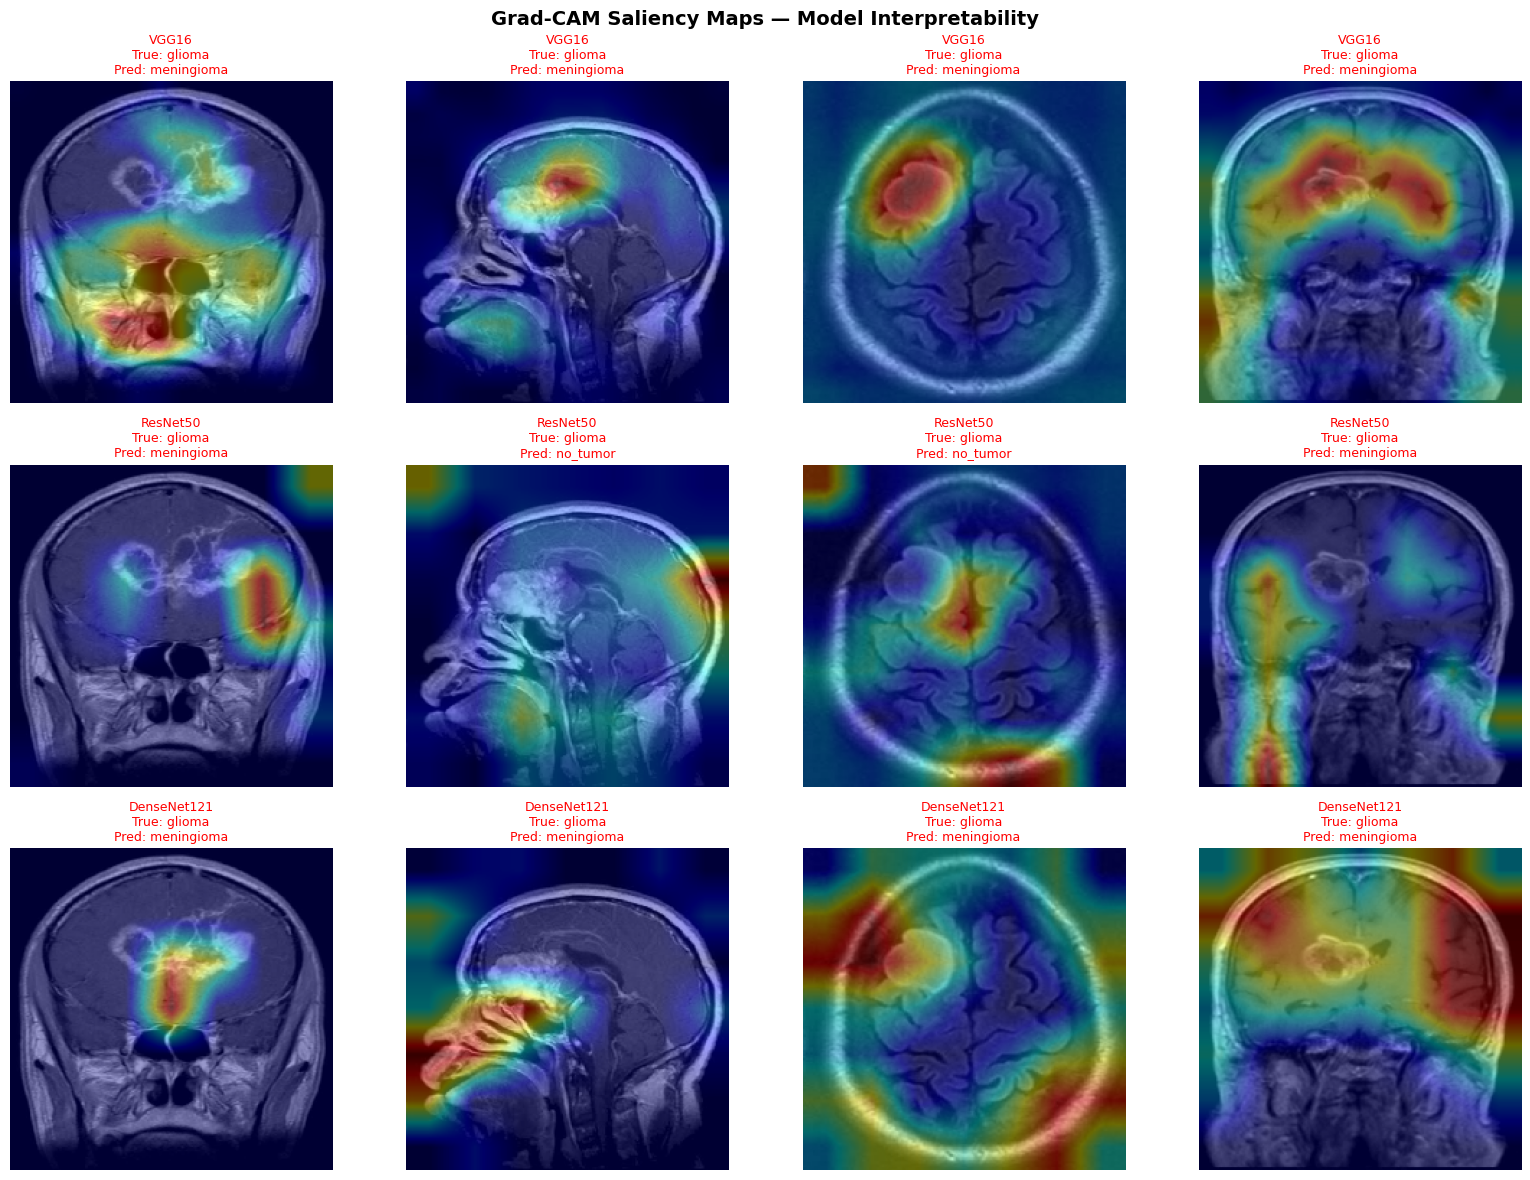

✅ Grad-CAM maps saved


In [15]:
import cv2

def get_gradcam_layer(model_name):
    return {'VGG16': 'block5_conv3',
            'ResNet50': 'conv5_block3_out',
            'DenseNet121': 'conv5_block16_concat'}[model_name]

def make_gradcam(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_heatmap(img, heatmap, alpha=0.4):
    hm = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(img * 255 * (1 - alpha) + hm * alpha)

# Get 4 test images (one per class)
test_gen.reset()
imgs_batch, labels_batch = next(test_gen)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM Saliency Maps — Model Interpretability', fontsize=14, fontweight='bold')

for row, (name, model) in enumerate(models_trained.items()):
    try:
        last_conv = get_gradcam_layer(name)
        for col in range(4):
            img = imgs_batch[col]
            img_arr = np.expand_dims(img, axis=0)
            heatmap, pred = make_gradcam(model, img_arr, last_conv)
            overlay = overlay_heatmap(img, heatmap)
            axes[row, col].imshow(overlay)
            true_cls = CLASS_NAMES[np.argmax(labels_batch[col])]
            pred_cls = CLASS_NAMES[pred]
            color = 'green' if true_cls == pred_cls else 'red'
            axes[row, col].set_title(
                f'{name}\nTrue: {true_cls}\nPred: {pred_cls}',
                fontsize=9, color=color
            )
            axes[row, col].axis('off')
    except Exception as e:
        print(f'Grad-CAM skipped for {name}: {e}')

plt.tight_layout()
plt.savefig('gradcam_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM maps saved')

## ✅ Step 15 — Download All Results

In [16]:
import zipfile, json

# Save summary JSON
summary = {
    name: {
        'accuracy' : round(float(r['accuracy']), 4),
        'precision': round(float(r['precision']), 4),
        'recall'   : round(float(r['recall']), 4),
        'f1'       : round(float(r['f1']), 4),
        'auc_roc'  : round(float(r['auc']), 4)
    }
    for name, r in results.items()
}
with open('results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Zip all outputs
output_files = [
    'sample_images.png', 'training_curves.png',
    'confusion_matrices.png', 'roc_curves.png',
    'model_comparison_bar.png', 'gradcam_maps.png',
    'results_summary.json'
]

with zipfile.ZipFile('dissertation_results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

print('\nFinal results summary:')
print(json.dumps(summary, indent=2))

# Download
files.download('dissertation_results.zip')
print('\n✅ All results downloaded!')

  Added: sample_images.png
  Added: training_curves.png
  Added: confusion_matrices.png
  Added: roc_curves.png
  Added: model_comparison_bar.png
  Added: gradcam_maps.png
  Added: results_summary.json

Final results summary:
{
  "VGG16": {
    "accuracy": 0.7259,
    "precision": 0.8191,
    "recall": 0.7088,
    "f1": 0.6774,
    "auc_roc": 0.9009
  },
  "ResNet50": {
    "accuracy": 0.5,
    "precision": 0.5717,
    "recall": 0.489,
    "f1": 0.4575,
    "auc_roc": 0.7322
  },
  "DenseNet121": {
    "accuracy": 0.6751,
    "precision": 0.7161,
    "recall": 0.6604,
    "f1": 0.636,
    "auc_roc": 0.8729
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All results downloaded!
